# Midterm 2 - Q2 and Q3

### Q2.

In [3]:
# Q2 – Setup and Inputs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy_financial as npf

In [4]:
# Liability cash flows (years 1 to 10)
cash_flows = np.array([
    100000, 184203, 204483, 135251, 266849,
    199442, 173710, 117794, 93335, 250272
])

# adding years
years = np.arange(1, 11)

# Discount rate
r = 0.08  # 8%

# Display the inputs
print("Liability Cash Flows (Years 1–10):")
for t, cf in zip(years, cash_flows):
    print(f"Year {t}: {cf:,}")

print(f"\nDiscount Rate: {r*100:.0f}%")


Liability Cash Flows (Years 1–10):
Year 1: 100,000
Year 2: 184,203
Year 3: 204,483
Year 4: 135,251
Year 5: 266,849
Year 6: 199,442
Year 7: 173,710
Year 8: 117,794
Year 9: 93,335
Year 10: 250,272

Discount Rate: 8%


In [5]:
# Q2 – Part (i): Duration of the Liability

# Step 1: Discount factors
discount_factors = 1 / (1 + r)**years

# Step 2: Pv of each cash flow
pv_cash_flows = cash_flows * discount_factors

# Step 3: PV of liabilities
total_pv = pv_cash_flows.sum()

# Step 4: Weights of each CF (PV_i / Total PV)
weights = pv_cash_flows / total_pv

# Step 5: Macaulay Duration
duration = np.sum(years * weights)

print(f"Duration of the liability: {duration:.3f} years") # 3 Decimals

Duration of the liability: 5.015 years


In [6]:
# Q2 – Part (ii): Cash flows contributing more than 11% of total PV

threshold = 0.11  # 11%

# What weights exceed threshold
indices = np.where(weights > threshold)[0]  # returns index positions

print("Cash flows contributing more than 11% of total PV:\n")
for idx in indices:
    year = years[idx]
    cf = cash_flows[idx]
    contribution_pct = weights[idx] * 100
    print(f"Year {year}: CF = {cf:,}  → Contribution = {contribution_pct:.2f}%")


Cash flows contributing more than 11% of total PV:

Year 2: CF = 184,203  → Contribution = 13.77%
Year 3: CF = 204,483  → Contribution = 14.15%
Year 5: CF = 266,849  → Contribution = 15.83%


In [7]:
# Q2 – Part (iii): Average of nondiscounted liability payments

avg_cf = np.mean(cash_flows)  # arithmetic mean of the 10 raw CFs

print(f"Average nondiscounted payment (exact): {avg_cf:.2f}")
print(f"Average nondiscounted payment (0 decimals, as required): {avg_cf:.0f}")


Average nondiscounted payment (exact): 172533.90
Average nondiscounted payment (0 decimals, as required): 172534


In [8]:
# Q2 – Part (iv): Duration of a fixed liability structure

def duration_fixed_liability(payment, years, discount_rate):
    """
    Computes the Macaulay duration of a fixed-payment liability.

    Parameters:
        payment (float): fixed payment each year
        years (int): number of total years
        discount_rate (float): discount rate (e.g., 0.08 for 8%)
        
    Returns:
        float: Macaulay duration
    """

    # Creating a array of year numbers
    t = np.arange(1, years + 1)

    # Discount factors
    discount_factors = 1 / (1 + discount_rate)**t

    # PV of each fixed payment
    pv_payments = payment * discount_factors

    # Total PV
    total_pv = pv_payments.sum()

    # Macaulay duration
    duration = np.sum(t * pv_payments) / total_pv

    return duration


# Average CF from part (iii) for fixed payment
fixed_payment = avg_cf
years_total = 10
discount_rate = r

duration_fixed = duration_fixed_liability(fixed_payment, years_total, discount_rate)

print(f"Duration of fixed-payment liability: {duration_fixed:.3f} years")

Duration of fixed-payment liability: 4.871 years


## Q3.

In [9]:
# Q3 Part i – Load data and compute monthly returns

df_q3_prices = pd.read_excel(
    "/Users/braydenb/Downloads/Midterm2/Midterm2.xlsx",
    sheet_name="Q3",
    index_col=0
)

display(df_q3_prices.head())

# Monthly returns
df_q3_returns = df_q3_prices.pct_change().dropna()

print("Monthly returns (first few rows):")
display(df_q3_returns.head())

# market returns
market_ret = df_q3_returns["SP500"]
stock_rets = df_q3_returns.drop(columns=["SP500"])

print("\nIndividual stock return columns:")
print(stock_rets.columns.tolist())


,BCS,BAC,JPM,C,BMO,M,DE,PG,SWK,PFE,AXP,NYT,WFC,TD,AAPL,AMZN,MSFT,IBM,SP500
date,,,,,,,,,,,,,,,,,,,
2000-01-01,9.444137,12.490797,25.481020,223.448822,5.332372,10.871688,13.243672,25.479961,12.818610,13.227181,33.865257,33.154583,9.864648,4.590513,0.777893,3.228125,29.949718,55.557552,1394.459961
2000-02-01,9.492320,11.862234,25.287760,202.868027,4.881327,9.582105,10.837457,22.215918,11.734449,11.742270,27.624060,30.660074,8.153743,4.613241,0.859431,3.443750,27.348722,50.855602,1366.420044
2000-03-01,10.845604,13.522300,27.689497,235.371277,5.716522,11.034926,11.519531,14.347125,13.456355,13.398168,30.660519,31.241610,10.104580,4.851855,1.018290,3.350000,32.512463,58.650761,1498.579956
2000-04-01,10.845604,12.774712,22.905861,231.931763,5.970817,8.880181,12.312965,15.105558,15.195655,15.436522,30.776304,29.968321,10.182076,4.240070,0.930191,2.759375,21.343477,55.244450,1452.430054
2000-05-01,10.549819,14.453019,23.843388,245.089325,6.621809,10.055499,12.675116,16.890381,13.843509,16.306826,33.407055,28.058348,11.220428,4.503644,0.629812,2.415625,19.144100,53.169697,1420.599976


Monthly returns (first few rows):


,BCS,BAC,JPM,C,BMO,M,DE,PG,SWK,PFE,AXP,NYT,WFC,TD,AAPL,AMZN,MSFT,IBM,SP500
date,,,,,,,,,,,,,,,,,,,
2000-02-01,0.005102,-0.050322,-0.007584,-0.092105,-0.084586,-0.118618,-0.181688,-0.128102,-0.084577,-0.112262,-0.184295,-0.075239,-0.173438,0.004951,0.104819,0.066796,-0.086845,-0.084632,-0.020108
2000-03-01,0.142566,0.139945,0.094976,0.160219,0.171100,0.151618,0.062937,-0.354196,0.146739,0.141020,0.109921,0.018967,0.239257,0.051724,0.184842,-0.027223,0.188811,0.153280,0.096720
2000-04-01,0.000000,-0.055286,-0.172760,-0.014613,0.044484,-0.195266,0.068877,0.052863,0.129255,0.152137,0.003776,-0.040756,0.007669,-0.126093,-0.086517,-0.176306,-0.343529,-0.058078,-0.030796
2000-05-01,-0.027272,0.131377,0.040930,0.056730,0.109029,0.132353,0.029412,0.118157,-0.088982,0.056380,0.085480,-0.063733,0.101978,0.062163,-0.322922,-0.124575,-0.103047,-0.037556,-0.021915
2000-06-01,-0.065421,-0.217227,-0.074895,-0.031156,0.063527,-0.123377,-0.109775,-0.146617,-0.116279,0.080761,-0.034722,0.027415,-0.139069,-0.010178,0.247025,-0.248383,0.278721,0.022198,0.023934



Individual stock return columns:
['BCS', 'BAC', 'JPM', 'C', 'BMO', 'M', 'DE', 'PG', 'SWK', 'PFE', 'AXP', 'NYT', 'WFC', 'TD', 'AAPL', 'AMZN', 'MSFT', 'IBM']


In [10]:
# Q3 Part ii – First pass regression

import statsmodels.api as sm  # Need to prevent regression error message

first_pass_results = []

# X same for every stock
X = sm.add_constant(market_ret)   # column for alpha + SP500 for beta

for ticker in stock_rets.columns:
    y = stock_rets[ticker]       # stock's excess return 
    
    model = sm.OLS(y, X).fit()
    
    beta = model.params["SP500"]  # CAPM beta
    avg_ret = y.mean()            # average monthly return
    
    first_pass_results.append([ticker, avg_ret, beta])

# Put into a dataframe: index = ticker, columns = AvgRet and Beta
df_first_pass = (pd.DataFrame(first_pass_results,
                              columns=["Ticker", "AvgRet", "Beta"])
                 .set_index("Ticker"))

print("First-pass regression results (AvgRet and Beta):")
display(df_first_pass)

First-pass regression results (AvgRet and Beta):


,AvgRet,Beta
Ticker,,
BCS,0.008140,1.565517
BAC,0.010235,1.479760
JPM,0.010879,1.325715
C,0.002819,1.780740
BMO,0.011924,0.977406
M,0.009541,1.550977
DE,0.014918,1.089613
PG,0.007566,0.298302
SWK,0.010088,1.206891


In [11]:
# Q3 Part iii – Second pass regression: AvgRet on Beta 

# X = Beta with a constant
X_2 = sm.add_constant(df_first_pass["Beta"])
y_2 = df_first_pass["AvgRet"]

second_pass_model = sm.OLS(y_2, X_2).fit()

print(second_pass_model.summary())

# Regression coefficient on Beta
beta_price_of_risk = second_pass_model.params["Beta"]
print(f"\nSecond-pass slope (coefficient on Beta): {beta_price_of_risk:.2f}") # 2 decimals

                            OLS Regression Results                            
Dep. Variable:                 AvgRet   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                 -0.022
Method:                 Least Squares   F-statistic:                    0.6314
Date:                Sun, 30 Nov 2025   Prob (F-statistic):              0.438
Time:                        21:37:38   Log-Likelihood:                 68.752
No. Observations:                  18   AIC:                            -133.5
Df Residuals:                      16   BIC:                            -131.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0072      0.005      1.508      0.1

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


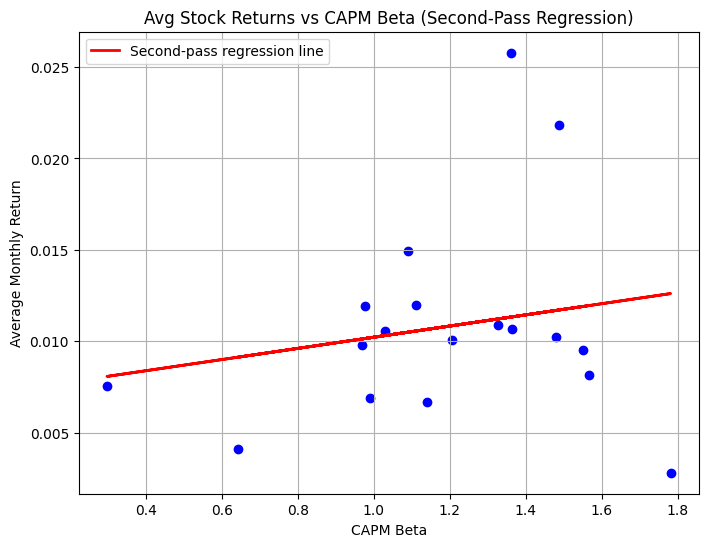

In [14]:
# Q3 – Part iv: Scatter plot of AvgRet vs Beta

plt.figure(figsize=(8,6))
plt.scatter(df_first_pass["Beta"], df_first_pass["AvgRet"], color="blue")

# Regression line
beta_vals = df_first_pass["Beta"]
predicted_line = second_pass_model.params["const"] + second_pass_model.params["Beta"] * beta_vals
plt.plot(beta_vals, predicted_line, color="red", linewidth=2, label="Second-pass regression line")

plt.xlabel("CAPM Beta")
plt.ylabel("Average Monthly Return")
plt.title("Avg Stock Returns vs CAPM Beta (Second-Pass Regression)")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Following "dont answer as markdown or plain text" rule
print("""The anticipated value of beta risk is almost 0 and the scatterplot shows no upward trajectory with beta and average returns. However, because the data fails to show
the risk-return trade-off expected from the CAPM, the model is not valid.""")

The anticipated value of beta risk is almost 0 and the scatterplot shows no upward trajectory with beta and average returns. However, because the data fails to show
the risk-return trade-off expected from the CAPM, the model is not valid.
